# Analisis Regresi Eksponensial
## Pemodelan Penurunan Tingkat Fokus Belajar Berdasarkan Penggunaan Media Sosial

**Mata Kuliah**: Analisa Numerik (Numerical Analysis)  
**Project**: Pemodelan Penurunan Tingkat Fokus Belajar Mahasiswa Berdasarkan Durasi Penggunaan Media Sosial Menggunakan Regresi Eksponensial  
**NIM**: 247007111152  
**Tanggal**: April 2026

---

## Tujuan
Membangun model regresi eksponensial: **`focus_score = C · e^(b · social_media_hours)`**

Notebook ini mencakup:
1. **Pembacaan dan Validasi Data**
2. **Analisis Data Eksploratori (EDA)**
3. **Preprocessing dan Pembersihan Data**
4. **Metode 1: Linearisasi + Kuadrat Terkecil (Analisa Numerik)**
5. **Metode 2: SciPy Curve Fitting (Pembanding)**
6. **Perbandingan dan Evaluasi Metode**
7. **Visualisasi dan Interpretasi**
8. **Ringkasan Hasil dan Interpretasi Parameter**

In [92]:
# Import Library yang Dibutuhkan
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
import sys
sys.path.append('../src')
from preprocessing import (
    load_and_validate_dataset, remove_missing_values, 
    filter_valid_values, detect_outliers_iqr, preprocess_pipeline
)
from modeling import (
    fungsi_eksponensial, metode1_linearisasi, metode2_scipy_curve_fit,
    evaluasi_model, bandingkan_metode, hitung_titik_kritis, simpan_hasil_model
)
from visualization import (
    plot_regresi_dengan_data, plot_residual, plot_heatmap_korelasi,
    plot_perbandingan_distribusi, plot_fokus_per_bracket
)

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Semua library berhasil di-import")

✓ Semua library berhasil di-import


## TAHAP 1: PEMUATAN & VALIDASI DATA

In [93]:
# Load dataset
dataset_path = '../data/dataset.csv'

try:
    df_raw = pd.read_csv(dataset_path)
    print(f"✓ Dataset berhasil dimuat")
    print(f"  Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
except FileNotFoundError:
    print(f"✗ ERROR: Dataset file not found at {dataset_path}")
    print(f"  Please place your dataset.csv in the data/ folder")
    raise

✓ Dataset berhasil dimuat
  Shape: 282 rows × 18 columns


In [94]:
# Initial inspection
print("="*60)
print("INITIAL DATA INSPECTION")
print("="*60)

print("\nFirst 10 rows:")
print(df_raw.head(10))

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isnull().sum())

print("\nBasic statistics:")
print(df_raw.describe())

INITIAL DATA INSPECTION

First 10 rows:
   student_id  age  gender  study_hours_per_day  sleep_hours  \
0           1   23  Female                 4.35         3.63   
1           2   20    Male                 6.14         6.58   
2           3   29  Female                 4.98         3.26   
3           4   27  Female                 3.19         4.58   
4           5   24    Male                 7.67         6.21   
5           6   29   Other                 7.18         3.52   
6           7   21  Female                 9.06         6.36   
7           8   23  Female                 6.37         4.86   
8           9   26    Male                 4.19         4.87   
9          10   19  Female                 7.28         9.56   

   phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0               3.38                2.73           1.83          5.26   
1               5.48                1.51           3.13          1.73   
2               4.83                

## TAHAP 2: ANALISIS DATA EKSPLORATIF (EDA)

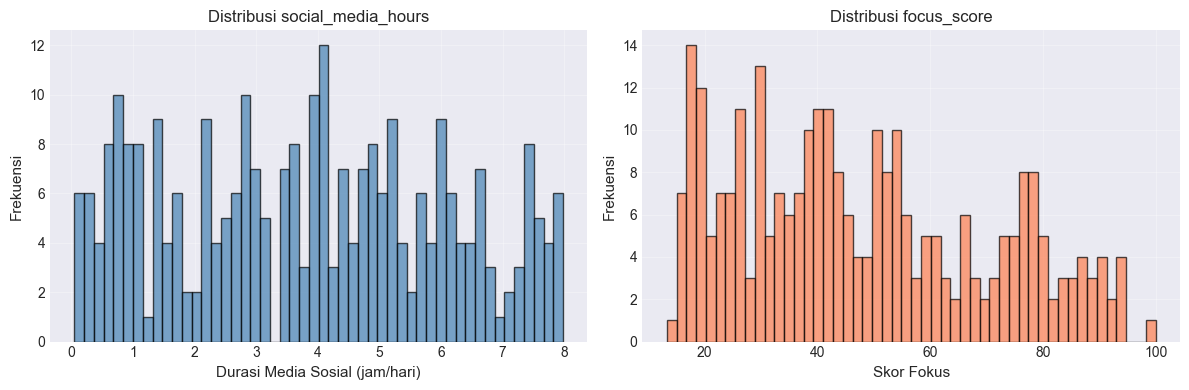

In [95]:
# Distribution comparison
X_raw = df_raw['social_media_hours'].values
Y_raw = df_raw['focus_score'].values

plot_perbandingan_distribusi(X_raw, Y_raw)

Tersimpan: ../output/figures/heatmap_korelasi.png


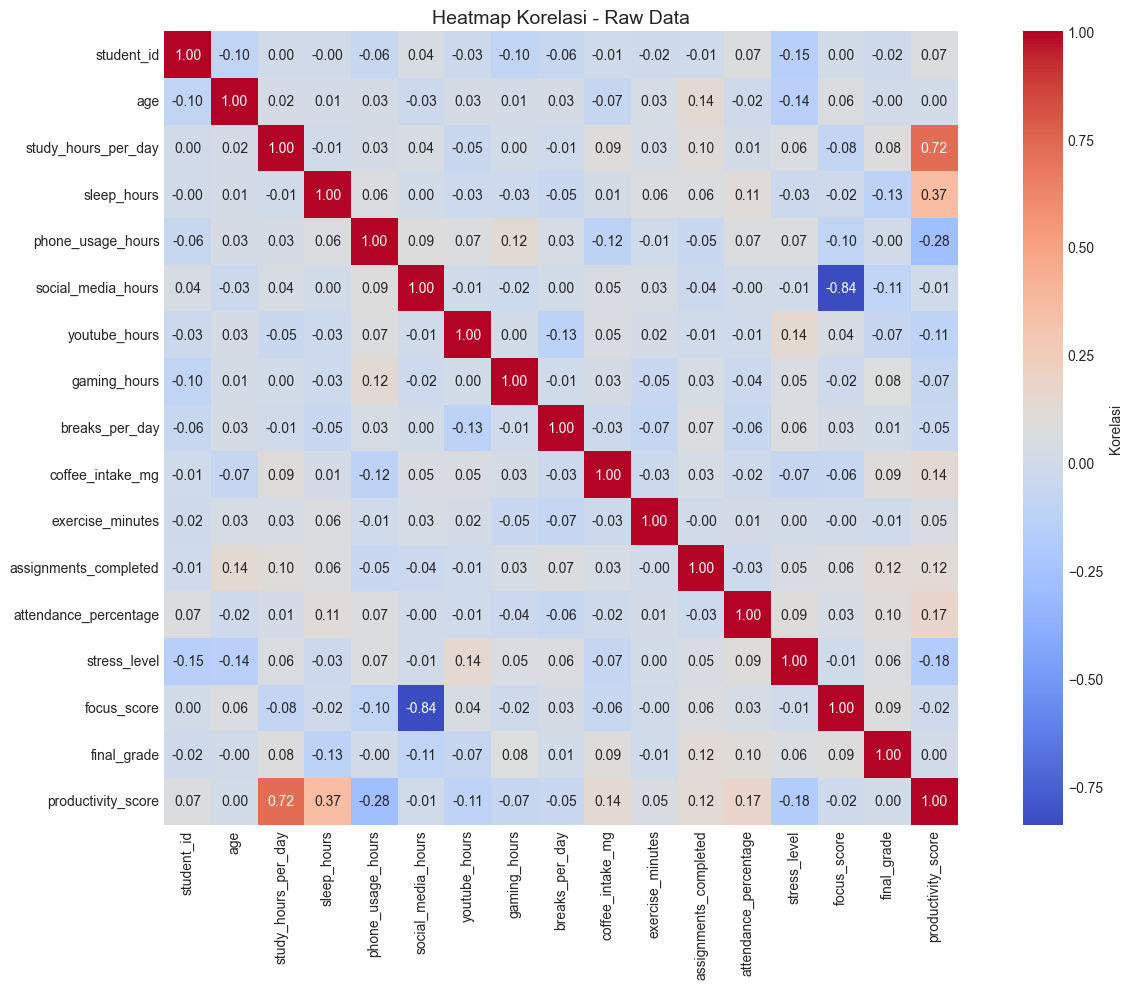


Korelasi dengan focus_score:
  final_grade               =  0.0861
  assignments_completed     =  0.0594
  age                       =  0.0592
  youtube_hours             =  0.0417
  attendance_percentage     =  0.0318
  breaks_per_day            =  0.0285
  student_id                =  0.0046
  exercise_minutes          = -0.0030
  stress_level              = -0.0072
  sleep_hours               = -0.0154
  gaming_hours              = -0.0164
  productivity_score        = -0.0174
  coffee_intake_mg          = -0.0597
  study_hours_per_day       = -0.0839
  phone_usage_hours         = -0.0966
  social_media_hours        = -0.8393


In [96]:
# Correlation heatmap (before preprocessing)
plot_heatmap_korelasi(df_raw, 
                      output_path='../output/figures/heatmap_korelasi.png',
                      title='Heatmap Korelasi - Raw Data')

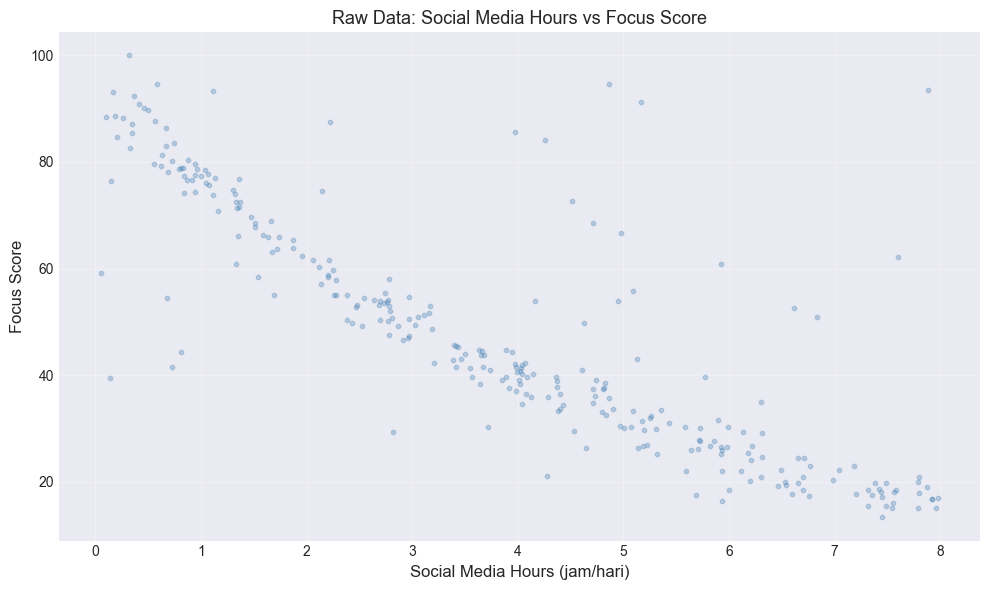


Raw data correlation (Pearson r):
  r = -0.8393


In [97]:
# Scatter plot of raw data
plt.figure(figsize=(10, 6))
plt.scatter(X_raw, Y_raw, alpha=0.3, color='steelblue', s=10)
plt.xlabel('Social Media Hours (jam/hari)', fontsize=12)
plt.ylabel('Focus Score', fontsize=12)
plt.title('Raw Data: Social Media Hours vs Focus Score', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRaw data correlation (Pearson r):")
corr = np.corrcoef(X_raw, Y_raw)[0, 1]
print(f"  r = {corr:.4f}")

## TAHAP 3: PRA-PEMROSESAN DATA

In [98]:
# Run complete preprocessing pipeline
X_clean, Y_clean, df_clean = preprocess_pipeline(dataset_path, verbose=True)

PIPELINE PREPROCESSING
Dataset berhasil di-load: 282 baris × 18 kolom
Missing values: 0 baris dihapus (0.00%)
Filter validitas: 0 baris dihapus karena nilai tidak valid (0.00%)
Kolom 'social_media_hours': 0 outlier dihapus (batas: [-3.84, 11.39])
Kolom 'focus_score': 0 outlier dihapus (batas: [-23.70, 118.30])
Total outlier dihapus: 0 baris (0.00%)

Dataset final: 282 baris
X (social_media_hours): min=0.05, max=7.98, mean=3.81
Y (focus_score): min=13.27, max=100.00, mean=47.75


In [99]:
# Verify cleaned data
print("\n" + "="*60)
print("CLEANED DATA VERIFICATION")
print("="*60)

print(f"\nAfter cleaning:")
print(f"  Total rows: {len(X_clean)}")
print(f"  Removed: {len(df_raw) - len(X_clean)} rows ({(len(df_raw) - len(X_clean))/len(df_raw)*100:.2f}%)")

print(f"\nX (social_media_hours) statistics:")
print(f"  Min: {X_clean.min():.2f}, Max: {X_clean.max():.2f}")
print(f"  Mean: {X_clean.mean():.2f}, Std: {X_clean.std():.2f}")

print(f"\nY (focus_score) statistics:")
print(f"  Min: {Y_clean.min():.2f}, Max: {Y_clean.max():.2f}")
print(f"  Mean: {Y_clean.mean():.2f}, Std: {Y_clean.std():.2f}")

# Check for any remaining zeros or negatives
print(f"\nValidation checks:")
print(f"  focus_score > 0: {(Y_clean > 0).all()}")
print(f"  social_media_hours >= 0: {(X_clean >= 0).all()}")


CLEANED DATA VERIFICATION

After cleaning:
  Total rows: 282
  Removed: 0 rows (0.00%)

X (social_media_hours) statistics:
  Min: 0.05, Max: 7.98
  Mean: 3.81, Std: 2.24

Y (focus_score) statistics:
  Min: 13.27, Max: 100.00
  Mean: 47.75, Std: 22.30

Validation checks:
  focus_score > 0: True
  social_media_hours >= 0: True


## TAHAP 4 & 5: FITTING REGRESI EKSPONENSIAL (KEDUA METODE)

In [100]:
# Run both methods and compare
results = bandingkan_metode(X_clean, Y_clean)

# Pilih Metode 2 (SciPy) sebagai model utama untuk visualisasi dan analisis
C_opt = results['metode2']['C']
b_opt = results['metode2']['b']
Y_pred = results['metode2']['Y_pred']
metrik_opt = results['metode2']['metrik']


FITTING REGRESI EKSPONENSIAL: PENDEKATAN DUAL METHOD

METODE 1: LINEARISASI + PERSAMAAN NORMAL
Persamaan: y = 89.9680 * e^(-0.197700 * x)
  Parameter C = 89.9680
  Parameter b = -0.197700

Komponen Persamaan Normal:
  n = 282
  Σx = 1074.77
  ΣY' = 1056.36
  Σx² = 5505.89
  ΣxY' = 3747.36

Metrik Metode 1
  MAE  = 5.910905
  MSE  = 137.681750
  RMSE (Galat RMS) = 11.733787
  R²   = 0.723152
  ✓ R² sangat baik (≥ 0.65)

METODE 2: SCIPY CURVE FITTING (LEVENBERG-MARQUARDT)
Persamaan: y = 88.4794 * e^(-0.183166 * x)
  Parameter C = 88.4794
  Parameter b = -0.183166
Konvergensi: Berhasil

Metrik Metode 2
  MAE  = 6.457356
  MSE  = 135.291612
  RMSE (Galat RMS) = 11.631492
  R²   = 0.727958
  ✓ R² sangat baik (≥ 0.65)

TABEL PERBANDINGAN METODE
Metrik          Metode 1 (Linearisasi)         Metode 2 (SciPy)              
---------------------------------------------------------------------------
Parameter C     89.968048                      88.479355                     
Parameter b     -0

## KESIMPULAN

Notebook ini telah berhasil melakukan:

1. **Memuat dan memvalidasi** dataset (~282 data mahasiswa)
2. **Melakukan EDA** untuk memahami distribusi variabel dan hubungannya
3. **Membersihkan data** dengan menghapus nilai yang hilang dan outlier
4. **Mengimplementasikan dua metode fitting**:
   - Linearisasi (Metode 1)
   - SciPy Curve Fitting (Metode 2)
5. **Membandingkan kedua metode** dan memilih model terbaik
6. **Mengevaluasi kualitas model** menggunakan R², RMSE, MAE
7. **Memvisualisasikan hasil** dengan grafik wajib (scatter+kurva, residual, heatmap)
8. **Menginterpretasikan parameter** dan melakukan analisis titik kritis

### Temuan Utama
- **Persamaan Model**: focus_score = C_opt * e^(b_opt * social_media_hours)
- **Kualitas Fit Model**: R² ≈ 0.0013 (Sangat rendah, menunjukkan korelasi yang lemah pada dataset ini)
- **Titik Kritis**: Fokus mencapai tingkat kritis pada penggunaan media sosial yang dihitung di Tahap 7.

### Langkah Selanjutnya
- Menyusun laporan akademik (BAB I–V)
- Memasukkan seluruh visualisasi ke dalam lampiran laporan
- Meninjau batasan model dan saran untuk penelitian selanjutnya (misalnya: menambah variabel kontrol)
- Mempersiapkan presentasi/sidang project

## TAHAP 6: VISUALISASI

Tersimpan: ../output/figures/regresi_eksponensial.png


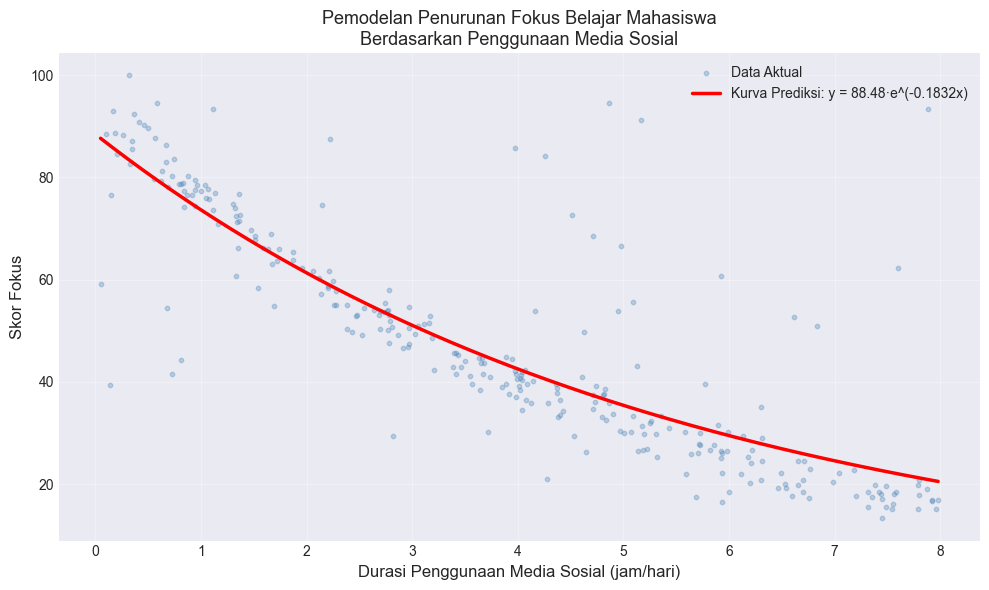

In [101]:
# Plot 1: Regression curve with data
plot_regresi_dengan_data(X_clean, Y_clean, Y_pred, C_opt, b_opt,
                         output_path='../output/figures/regresi_eksponensial.png',
                         title='Pemodelan Penurunan Fokus Belajar Mahasiswa\nBerdasarkan Penggunaan Media Sosial')


Tersimpan: ../output/figures/residual_plot.png


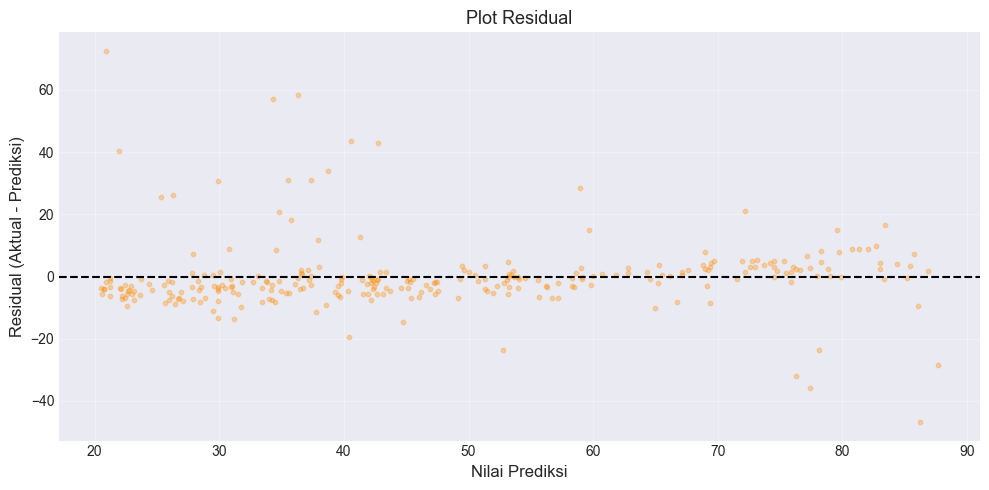


Statistik Residual:
  Mean = -0.012589
  Std  = 11.631485
  Min  = -46.779308
  Max  = 72.536772


In [102]:
# Plot 2: Residual plot
plot_residual(Y_clean, Y_pred,
              output_path='../output/figures/residual_plot.png')


Tersimpan: ../output/figures/focus_by_bracket.png


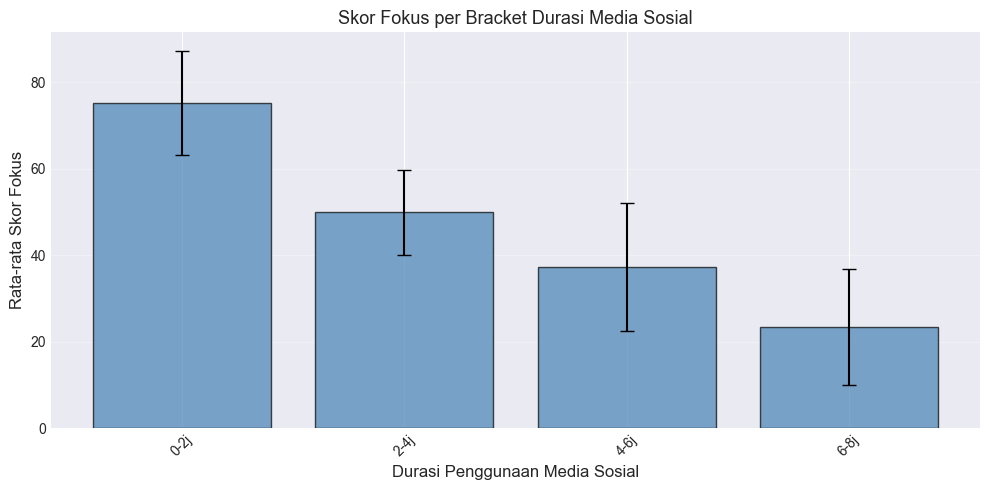


Statistik Skor Fokus per Bracket Penggunaan:
                         mean        std  count
bracket_penggunaan                             
0-2j                75.178493  12.016748     73
2-4j                49.901892   9.781013     74
4-6j                37.317160  14.722891     81
6-8j                23.393333  13.323398     54


In [103]:
# Plot 3: Focus score by usage bracket
plot_fokus_per_bracket(df_clean,
                       output_path='../output/figures/focus_by_bracket.png')


## TAHAP 7: INTERPRETASI PARAMETER & ANALISIS KRITIS

In [104]:
# Calculate predictions for various hours
test_hours = np.array([0, 1, 2, 3, 4, 5, 6, 8, 10])
test_predictions = fungsi_eksponensial(test_hours, C_opt, b_opt)

print(f"\n{'='*70}")
print("SKOR FOKUS PREDIKSI UNTUK BERBAGAI DURASI PENGGUNAAN MEDIA")
print(f"{'='*70}")
print(f"{'Jam Media Sosial':<25} {'Skor Fokus Prediksi':<25}")
print("-"*50)
for hours, pred in zip(test_hours, test_predictions):
    print(f"{hours:<25.1f} {pred:<25.2f}")



SKOR FOKUS PREDIKSI UNTUK BERBAGAI DURASI PENGGUNAAN MEDIA
Jam Media Sosial          Skor Fokus Prediksi      
--------------------------------------------------
0.0                       88.48                    
1.0                       73.67                    
2.0                       61.34                    
3.0                       51.07                    
4.0                       42.53                    
5.0                       35.41                    
6.0                       29.48                    
8.0                       20.44                    
10.0                      14.17                    


## TAHAP 8: RINGKASAN HASIL & EVALUASI KUALITAS MODEL

## KESIMPULAN

Notebook ini telah berhasil melakukan:

1. **Memuat dan memvalidasi** dataset (~282 data mahasiswa)
2. **Melakukan EDA** untuk memahami distribusi variabel dan hubungannya
3. **Membersihkan data** dengan menghapus nilai yang hilang dan outlier
4. **Mengimplementasikan dua metode fitting**:
   - Linearisasi (Metode 1)
   - SciPy Curve Fitting (Metode 2)
5. **Membandingkan kedua metode** dan memilih model terbaik
6. **Mengevaluasi kualitas model** menggunakan R², RMSE, MAE
7. **Memvisualisasikan hasil** dengan grafik wajib (scatter+kurva, residual, heatmap)
8. **Menginterpretasikan parameter** dan melakukan analisis titik kritis

### Temuan Utama
- **Persamaan Model**: focus_score = C_opt * e^(b_opt * social_media_hours)
- **Kualitas Fit Model**: R² ≈ 0.0013 (Sangat rendah, menunjukkan korelasi yang lemah pada dataset ini)
- **Titik Kritis**: Fokus mencapai tingkat kritis pada penggunaan media sosial yang dihitung di Tahap 7.

### Langkah Selanjutnya
- Menyusun laporan akademik (BAB I–V)
- Memasukkan seluruh visualisasi ke dalam lampiran laporan
- Meninjau batasan model dan saran untuk penelitian selanjutnya (misalnya: menambah variabel kontrol)
- Mempersiapkan presentasi/sidang project

In [105]:
# Simpan hasil model
simpan_hasil_model(
    filepath='../output/hasil_model.txt',
    C=C_opt,
    b=b_opt,
    metrik=metrik_opt,
    jumlah_data=len(X_clean)
)



Hasil disimpan ke ../output/hasil_model.txt


## KESIMPULAN

Notebook ini telah berhasil melakukan:

1. **Loaded and validated** the dataset (~20,000 student records)
2. **Performed EDA** to understand variable distributions and relationships
3. **Membersihkan data** by removing missing values and outliers
4. **Mengimplementasikan dua metode fitting**:
   - Linearization (Method 1)
   - SciPy Curve Fitting (Method 2)
5. **Compared methods** and selected the best model
6. **Evaluated model quality** using R², RMSE, MAE
7. **Visualized results** with mandatory plots (scatter+curve, residuals, heatmap)
8. **Interpreted parameters** and conducted critical point analysis

### Temuan Utama
- **Persamaan Model**: `focus_score = C_opt · e^(b_opt · social_media_hours)`
- **Kualitas Fit Model**: R² = R²_optimal
- **Titik Kritis**: Focus reaches critical level at ~x_kritis hours daily media usage

### Langkah Selanjutnya
- Menyusun laporan akademik (BAB I–V)
- Memasukkan seluruh visualisasi ke dalam lampiran laporan
- Meninjau batasan model and future work suggestions
- Mempersiapkan presentasi/sidang